# Creating fun stuff

In [1]:
# ── dependencies ──────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.widgets import Slider
import nibabel as nib
from pathlib import Path


In [2]:
# interactive backend — use 'inline' if widget not available
%matplotlib widget

In [3]:
sample_lf_in_vivo_img = nib.load(r"E:\msc_data\sc_qsm\final_gauss_sims\feb_2026\gt_data\realistic_noise\di_opt_input_lf_ref_avg_onlySC_lf_Hz.nii.gz")
sample_lf_data = sample_lf_in_vivo_img.get_fdata()

In [ ]:
# ── 1. COMPUTE K-SPACE ────────────────────────────────────────────────────────
# 3D FFT → shift DC to centre → take log-magnitude for display
kspace      = np.fft.fftshift(np.fft.fftn(sample_lf_data))
kspace_mag  = np.abs(kspace)

# Logged magnitude
kspace_log  = np.log1p(kspace_mag)

# Normalise to [0, 1] for easy thresholding
kspace_norm = kspace_log / kspace_log.max()

cx, cy, cz  = [s // 2 for s in kspace_norm.shape]   # centre indices

print(f"K-space shape: {kspace_norm.shape}")
print(f"Centre voxel:  ({cx}, {cy}, {cz})")

K-space shape: (301, 351, 128)
Centre voxel:  (150, 175, 64)


C:\Users\Admin\AppData\Local\Temp\ipykernel_47008\1120843805.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


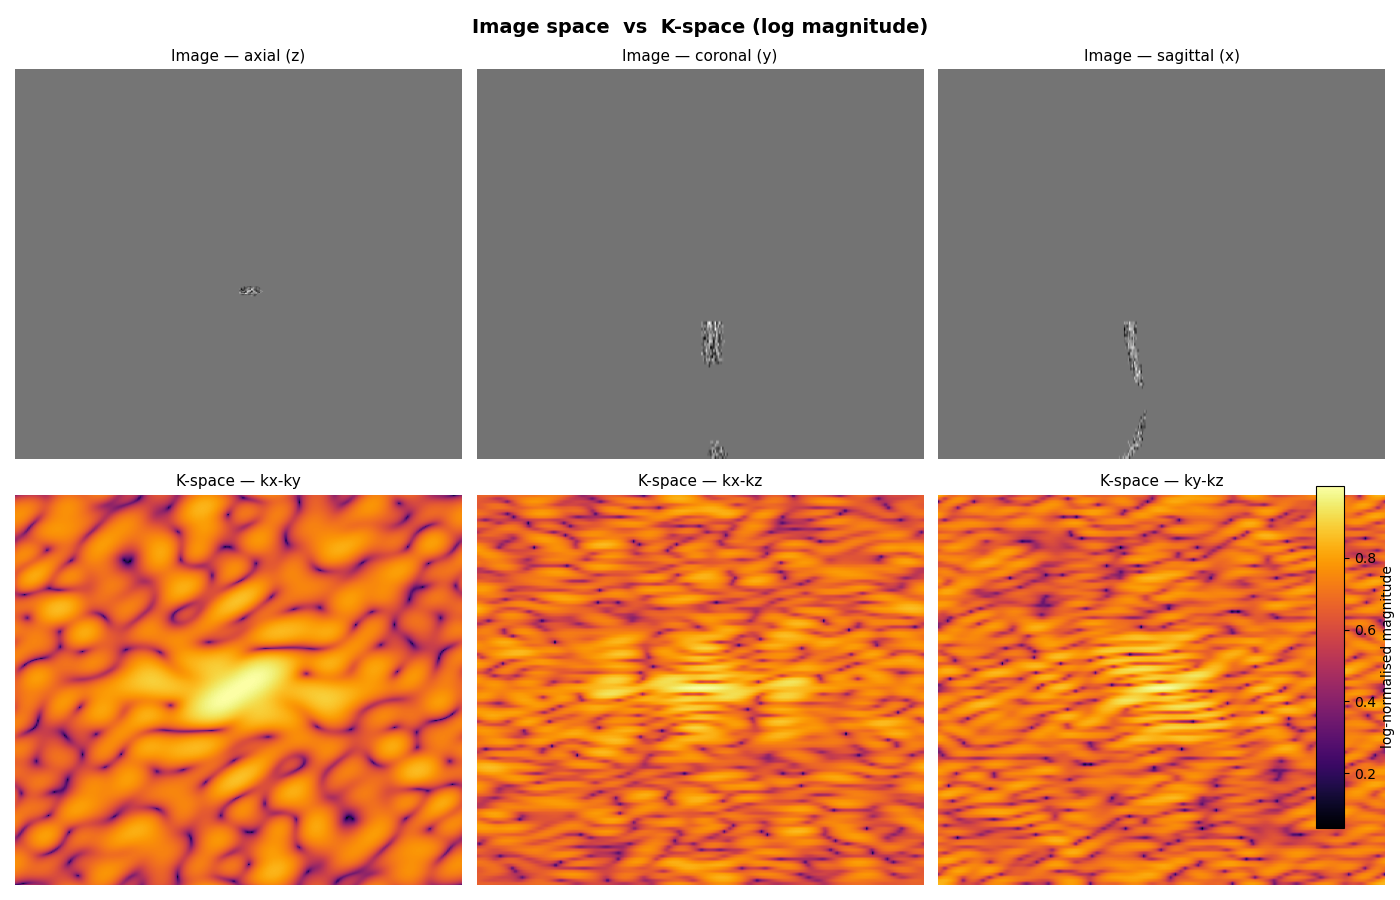

In [ ]:
# ── STATIC OVERVIEW — image + 3 k-space central slices ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
fig.suptitle("Image space  vs  K-space (log magnitude)", fontsize=14, fontweight="bold")

cmap_img = "gray"
cmap_k   = "inferno"

# Row 0 — image slices
titles_img = ["Image — axial (z)", "Image — coronal (y)", "Image — sagittal (x)"]
slices_img = [sample_lf_data[:, :, 38], sample_lf_data[:, 150, :], sample_lf_data[160, :, :]]
for ax, sl, title in zip(axes[0], slices_img, titles_img):
    ax.imshow(sl.T, cmap=cmap_img, origin="lower", aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.axis("off")

# Row 1 — k-space slices
titles_k  = ["K-space — kx-ky", "K-space — kx-kz", "K-space — ky-kz"]
slices_k  = [kspace_norm[:, :, cz], kspace_norm[:, cy, :], kspace_norm[cx, :, :]]
for ax, sl, title in zip(axes[1], slices_k, titles_k):

    im = ax.imshow(sl.T, cmap=cmap_k, origin="lower", aspect="auto")
    ax.set_title(title, fontsize=11)
    ax.axis("off")

# Put the colorbar outside of the kspace img
plt.tight_layout(rect=[0, 0, 0.92, 1])       # reserve 8% on the right BEFORE layout
cbar_ax = fig.add_axes([0.94, 0.08, 0.02, 0.38])  # manually place a thin axes there
fig.colorbar(im, cax=cbar_ax, label="log-normalised magnitude")    # attach colorbar to that dedicated axes
plt.tight_layout()
plt.show()

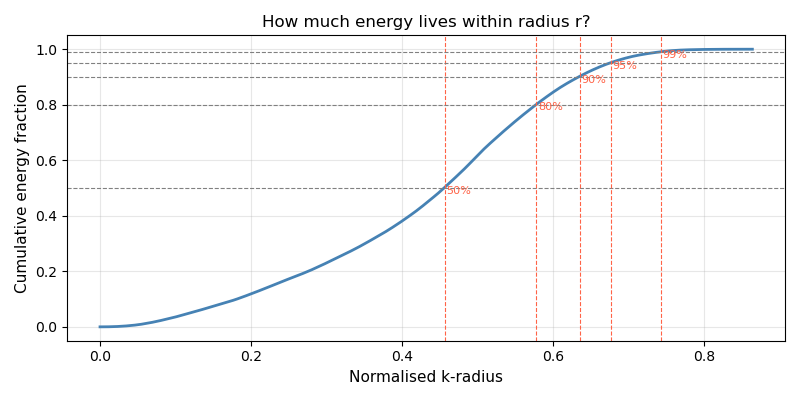

In [6]:
# ── 3. ENERGY DISTRIBUTION — how much signal lives at each k-radius? ─────────
# Build a radial k-space coordinate grid
nx, ny, nz = kspace_norm.shape
kx = np.fft.fftshift(np.fft.fftfreq(nx))
ky = np.fft.fftshift(np.fft.fftfreq(ny))
kz = np.fft.fftshift(np.fft.fftfreq(nz))
KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")
K_rad       = np.sqrt(KX**2 + KY**2 + KZ**2)

# Cumulative energy as a function of radius
radii      = np.linspace(0, K_rad.max(), 300)
energy_raw = kspace_mag**2
cum_energy = np.array([(energy_raw[K_rad <= r]).sum() for r in radii])
cum_energy /= cum_energy[-1]   # normalise

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(radii, cum_energy, color="steelblue", lw=2)
for pct in [0.5, 0.8, 0.9, 0.95, 0.99]:
    r_pct = radii[np.searchsorted(cum_energy, pct)]
    ax.axhline(pct, color="gray", lw=0.8, ls="--")
    ax.axvline(r_pct, color="tomato", lw=0.8, ls="--")
    ax.text(r_pct + 0.002, pct - 0.02, f"{int(pct*100)}%", fontsize=8, color="tomato")

ax.set_xlabel("Normalised k-radius", fontsize=11)
ax.set_ylabel("Cumulative energy fraction", fontsize=11)
ax.set_title("How much energy lives within radius r?", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

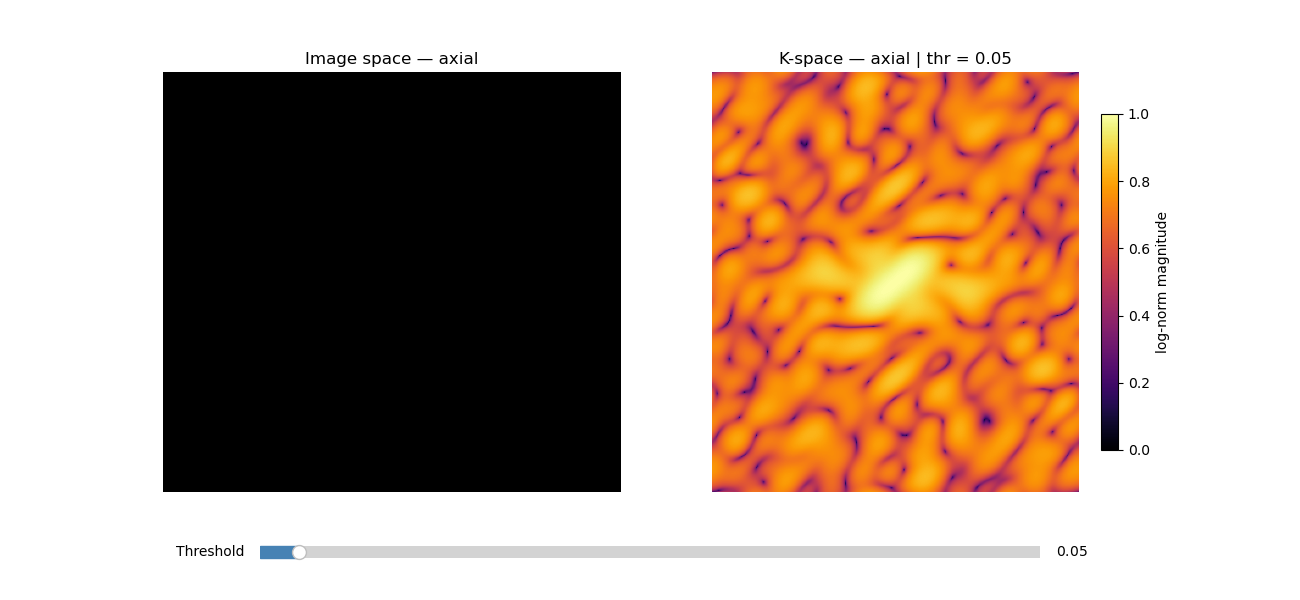

In [7]:
# ── 4. INTERACTIVE THRESHOLD ─────────────────────────────────────────────────
# Mask k-space to only show voxels ABOVE threshold → reveals the energy support shape
#
# Drag the slider to watch the shape emerge!
# Low threshold  → see the full blob
# High threshold → only the brightest (low-freq / DC region) survives

PLANE = "axial"   # change to 'coronal' or 'sagittal'

def get_slice(vol, plane):
    cx, cy, cz = [s // 2 for s in vol.shape]
    if plane == "axial":    return vol[:, :, cz]
    if plane == "coronal":  return vol[:, cy, :]
    if plane == "sagittal": return vol[cx, :, :]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
plt.subplots_adjust(bottom=0.18)

sl_k   = get_slice(kspace_norm, PLANE)
sl_img = get_slice(sample_lf_data, PLANE)

# Left panel — image (static reference)
axes[0].imshow(sl_img.T, cmap="gray", origin="lower", aspect="auto")
axes[0].set_title(f"Image space — {PLANE}", fontsize=12)
axes[0].axis("off")

# Right panel — thresholded k-space
init_thr = 0.05
masked   = np.where(sl_k >= init_thr, sl_k, np.nan)
im_k     = axes[1].imshow(masked.T, cmap="inferno", origin="lower", aspect="auto",
                            vmin=0, vmax=1)
title_k  = axes[1].set_title(f"K-space — {PLANE} | thr = {init_thr:.2f}", fontsize=12)
axes[1].axis("off")
plt.colorbar(im_k, ax=axes[1], label="log-norm magnitude", shrink=0.8)

# Slider
ax_slider = plt.axes([0.2, 0.06, 0.6, 0.04])
slider    = Slider(ax_slider, "Threshold", 0.0, 1.0, valinit=init_thr, color="steelblue")

def update(val):
    thr    = slider.val
    masked = np.where(sl_k >= thr, sl_k, np.nan)
    im_k.set_data(masked.T)
    title_k.set_text(f"K-space — {PLANE} | thr = {thr:.3f}  |  "
                     f"{100*(sl_k >= thr).mean():.1f}% of k-space retained")
    fig.canvas.draw_idle()

slider.on_changed(update)
plt.show()

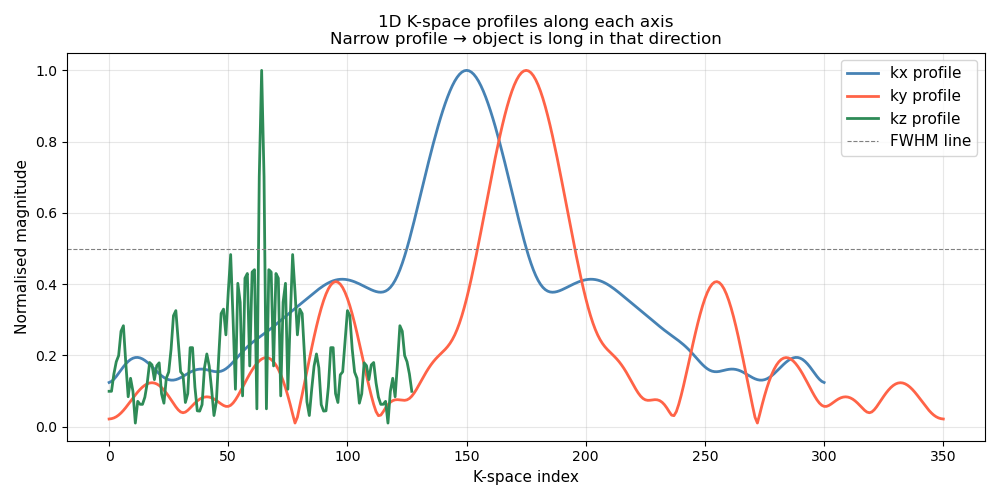

FWHM (k-space samples):
  kx: 50  (narrow = object wide in x)
  ky: 40  (narrow = object wide in y)
  kz: 2  (narrow = object wide in z)


In [9]:
# ── ANISOTROPY ANALYSIS ────────────────────────────────────────────────────
# How anisotropic is the k-space energy? Compare energy profiles along each axis.
# If the spine is elongated along z, expect the kz profile to be NARROWER.

# 1D profiles through k-space centre
prof_kx = kspace_mag[:, cy, cz]
prof_ky = kspace_mag[cx, :, cz]
prof_kz = kspace_mag[cx, cy, :]

# Normalise each
norm = lambda x: x / x.max()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(norm(prof_kx), label="kx profile", color="steelblue", lw=2)
ax.plot(norm(prof_ky), label="ky profile", color="tomato",    lw=2)
ax.plot(norm(prof_kz), label="kz profile", color="seagreen",  lw=2)
ax.axhline(0.5, color="gray", ls="--", lw=0.8, label="FWHM line")

ax.set_xlabel("K-space index", fontsize=11)
ax.set_ylabel("Normalised magnitude", fontsize=11)
ax.set_title("1D K-space profiles along each axis\n"
             "Narrow profile → object is long in that direction", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print FWHM for each axis
def fwhm(profile):
    p = norm(profile)
    above = np.where(p >= 0.5)[0]
    return above[-1] - above[0] if len(above) else np.nan

print("FWHM (k-space samples):")
print(f"  kx: {fwhm(prof_kx)}  (narrow = object wide in x)")
print(f"  ky: {fwhm(prof_ky)}  (narrow = object wide in y)")
print(f"  kz: {fwhm(prof_kz)}  (narrow = object wide in z)")